# Plano de parámetros — Método de Schröder

Reproducción en Python del dibujo del archivo Mathematica `fuentes mathematica/plano_parametros_sch_unificado.nb`.

Para cada parámetro \(\lambda = x + i y\), se itera el mapa del método de Schröder asociado al polinomio \(p(z)=(z^2-1)(z-\lambda)\), partiendo de los tres puntos críticos libres del mapa (raíces de un cúbico en `z`). Se colorea en blanco cuando alguna de esas órbitas converge a alguna raíz de `p` (1, -1 o \(\lambda\)) y en negro en caso contrario.


Calculando plano 1: [-0.375,0.375] x [0.0,0.7]
Los 3 puntos críticos DEBEN converger para pintar de blanco
fila 1/512 (y=0.7)
fila 65/512 (y=0.612329)
fila 65/512 (y=0.612329)
fila 129/512 (y=0.524658)
fila 129/512 (y=0.524658)
fila 193/512 (y=0.436986)
fila 193/512 (y=0.436986)
fila 257/512 (y=0.349315)
fila 257/512 (y=0.349315)
fila 321/512 (y=0.261644)
fila 321/512 (y=0.261644)
fila 385/512 (y=0.173973)
fila 385/512 (y=0.173973)
fila 449/512 (y=0.0863014)
fila 449/512 (y=0.0863014)

Blancos: 172970 (66.0%), Negros: 89174 (34.0%)

Blancos: 172970 (66.0%), Negros: 89174 (34.0%)
Imagen guardada en: img\plano_param_sch_1.png
Imagen guardada en: img\plano_param_sch_1.png


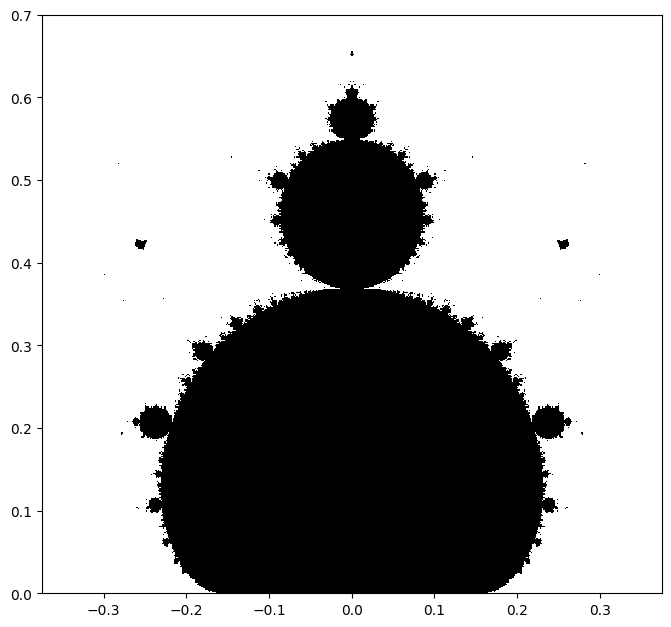

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

def iter_schroder(z: complex, lam: complex) -> complex:
    """
    Iteración de Schröder para p(z) = (z^2 - 1)(z - lam).
    Forma racional extraída de la notebook de Mathematica.
    """
    # Numerador: 4 z^3 + lam - 10 z^2 lam + z^4 lam + 4 z lam^2
    num = 4*z**3 + lam - 10*(z**2)*lam + (z**4)*lam + 4*z*(lam**2)
    # Denominador: 1 + 3 z^4 - 4 z lam - 4 z^3 lam + 2 lam^2 + 2 z^2 lam^2
    den = (1 + 3*z**4 - 4*z*lam - 4*(z**3)*lam + 2*(lam**2) + 2*(z**2)*(lam**2))
    return num / den

def critical_points_of_map(lam: complex):
    """
    Raíces en z del cúbico: (3 + lam^2) z^3 - 12 lam z^2 + (3 + 9 lam^2) z - 2 (lam + lam^3) = 0
    (tomado de `soluciones = Solve[ ... , z]` en el .nb)
    """
    a = 3 + lam**2
    b = -12*lam
    c = 3 + 9*(lam**2)
    d = -2*(lam + lam**3)
    coeffs = np.array([a, b, c, d], dtype=np.complex128)
    return np.roots(coeffs)

def converged_to_root(z: complex, lam: complex, eps: float = 1e-6) -> bool:
    """Verifica si z converge a alguna raíz: 1, -1, o lambda"""
    if abs(z - 1.0) < eps:
        return True
    if abs(z - (-1.0)) < eps:
        return True
    if abs(z - lam) < eps:
        return True
    return False

def iterate_from_seed(z0: complex, lam: complex, lim: int) -> bool:
    """
    Itera desde z0 hasta convergencia o lim iteraciones.
    Retorna True si converge a alguna raíz, False en caso contrario.
    """
    z = z0
    
    # Verificar si el punto crítico ya está en una raíz (caso especial)
    if converged_to_root(z, lam):
        return True
    
    # Iterar hasta lim veces
    for _ in range(lim):
        try:
            z = iter_schroder(z, lam)
            # Verificar valores no finitos
            if not np.isfinite(z.real) or not np.isfinite(z.imag):
                return False
            # Verificar convergencia después de iterar
            if converged_to_root(z, lam):
                return True
        except (ZeroDivisionError, OverflowError):
            return False
    
    # No convergió en lim iteraciones
    return False

def compute_parameter_plane(xmin, xmax, ymin, ymax, points=512, lim=100, verbose=False):
    """
    Calcula el plano de parámetros siguiendo la lógica del .nb de Mathematica.
    Para cada lambda, itera desde cada uno de los 3 puntos críticos.
    IMPORTANTE: Los 3 puntos críticos DEBEN converger para pintar de blanco.
    Si alguno no converge, se pinta de negro.
    """
    xs = np.linspace(xmin, xmax, points)
    ys = np.linspace(ymax, ymin, points)
    img = np.zeros((points, points), dtype=np.float32)
    
    for j, y in enumerate(ys):
        if verbose and j % max(1, (points // 8)) == 0:
            print(f'fila {j+1}/{points} (y={y:.6g})')
        for i, x in enumerate(xs):
            lam = complex(x, y)
            cps = critical_points_of_map(lam)
            
            # Probar TODOS los puntos críticos
            # TODOS deben converger para pintar de blanco
            all_converged = True
            for z0 in cps:
                if not iterate_from_seed(z0, lam, lim):
                    # Si uno no converge, ya es negro
                    all_converged = False
                    break
            
            img[j, i] = 1.0 if all_converged else 0.0
    
    return img, xs, ys

def plot_plane(img, xs, ys, title=None, filename=None):
    """
    Muestra y opcionalmente guarda el plano de parámetros.
    
    Args:
        img: Array con la imagen (0=negro, 1=blanco)
        xs, ys: Arrays con los valores de x e y
        title: Título opcional para la figura
        filename: Si se proporciona, guarda la imagen en img/<filename>.png
    """
    extent = [xs[0], xs[-1], ys[-1], ys[0]]
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray', origin='upper', extent=extent, interpolation='nearest')
    # plt.xlabel('Re(λ)')
    # plt.ylabel('Im(λ)')
    # if title:
    #     plt.title(title)
    
    # Guardar si se especifica filename
    if filename:
        # Crear carpeta img si no existe
        img_dir = 'img'
        if not os.path.exists(img_dir):
            os.makedirs(img_dir)
        
        filepath = os.path.join(img_dir, f'{filename}.png')
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f'Imagen guardada en: {filepath}')
    
    plt.show()

# Parámetros para el plot 1
number_points = 512
lim_iterations = 150
xx_min, xx_max = -0.375, 0.375
yy_min, yy_max = 0.0, 0.7

print(f"Calculando plano 1: [{xx_min},{xx_max}] x [{yy_min},{yy_max}]")
print(f"Los 3 puntos críticos DEBEN converger para pintar de blanco")
img, xs, ys = compute_parameter_plane(xx_min, xx_max, yy_min, yy_max,
                                      points=number_points, lim=lim_iterations, verbose=True)
white = int(np.sum(img))
black = number_points**2 - white
print(f"\nBlancos: {white} ({100*white/number_points**2:.1f}%), Negros: {black} ({100*black/number_points**2:.1f}%)")

plot_plane(img, xs, ys, 
          title=f'Plano Schröder: ({xx_min},{xx_max})x({yy_min},{yy_max}), {number_points}pts, {lim_iterations}it',
          filename='plano_param_sch_1')


Calculando plano 2: [-5,5] x [-5,5]
Los 3 puntos críticos DEBEN converger para pintar de blanco
fila 1/1024 (y=5)
fila 129/1024 (y=3.74878)
fila 129/1024 (y=3.74878)
fila 257/1024 (y=2.49756)
fila 257/1024 (y=2.49756)
fila 385/1024 (y=1.24633)
fila 385/1024 (y=1.24633)
fila 513/1024 (y=-0.00488759)
fila 513/1024 (y=-0.00488759)
fila 641/1024 (y=-1.25611)
fila 641/1024 (y=-1.25611)
fila 769/1024 (y=-2.50733)
fila 769/1024 (y=-2.50733)
fila 897/1024 (y=-3.75855)
fila 897/1024 (y=-3.75855)

Blancos: 922504 (88.0%), Negros: 126072 (12.0%)

Blancos: 922504 (88.0%), Negros: 126072 (12.0%)
Imagen guardada en: img\plano_param_sch_2.png
Imagen guardada en: img\plano_param_sch_2.png


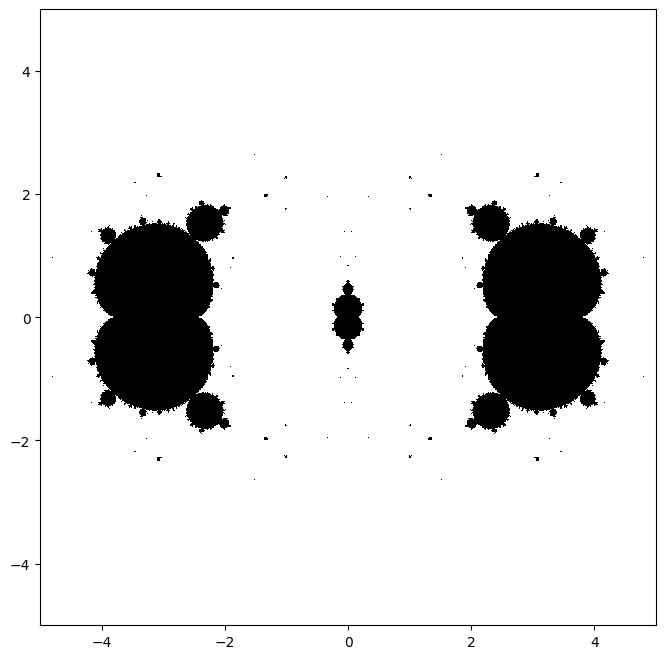

In [22]:
# Parámetros para el plot 2 (rango más grande)
number_points = 1024
lim_iterations = 150
xx_min, xx_max = -5, 5
yy_min, yy_max = -5, 5

print(f"Calculando plano 2: [{xx_min},{xx_max}] x [{yy_min},{yy_max}]")
print(f"Los 3 puntos críticos DEBEN converger para pintar de blanco")
img, xs, ys = compute_parameter_plane(xx_min, xx_max, yy_min, yy_max,
                                      points=number_points, lim=lim_iterations, verbose=True)
white = int(np.sum(img))
black = number_points**2 - white
print(f"\nBlancos: {white} ({100*white/number_points**2:.1f}%), Negros: {black} ({100*black/number_points**2:.1f}%)")

plot_plane(img, xs, ys, 
          title=f'Plano Schröder: ({xx_min},{xx_max})x({yy_min},{yy_max}), {number_points}pts, {lim_iterations}it',
          filename='plano_param_sch_2')
